Storm: AL092021
Max wind: 130.0 kts
Duration: 222.0 hours
Total Distance: 5627.9 km
RI events:
2021-08-26 18:00 → 2021-08-27 18:00 | +35 kt
2021-08-28 12:00 → 2021-08-29 12:00 | +60 kt


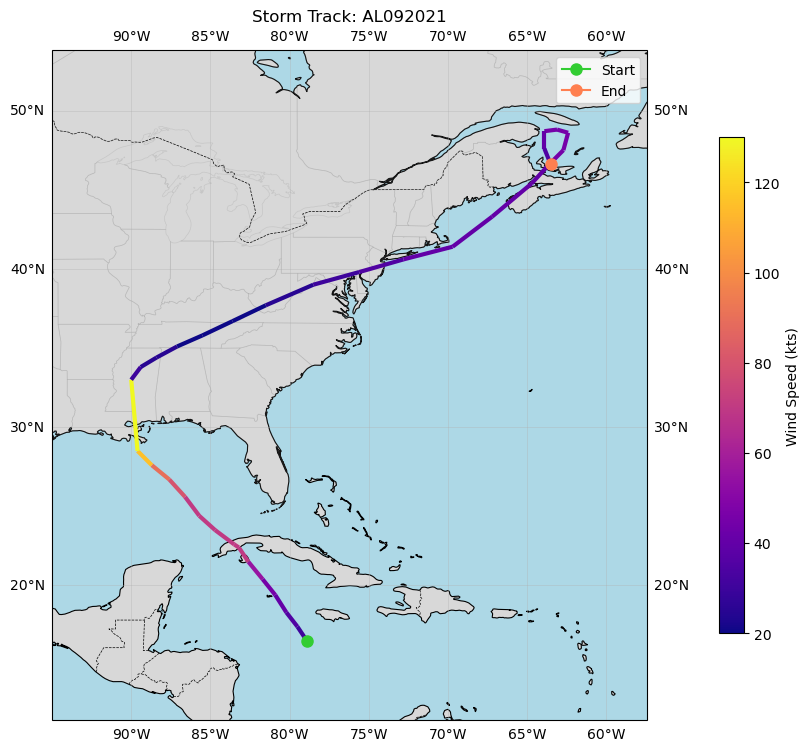

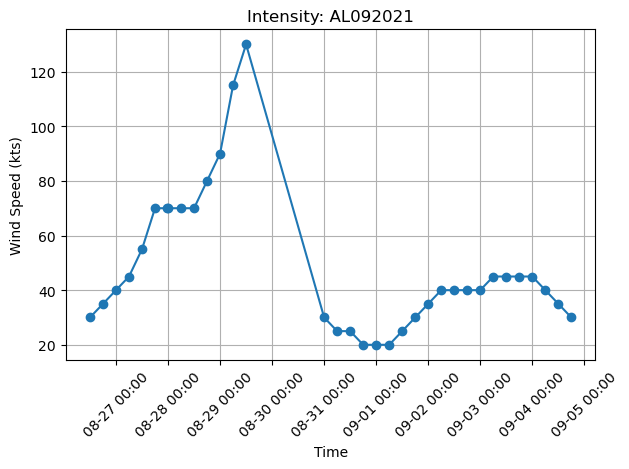

In [1]:
from tc_track_analyzer.core import StormTrack, IntensityAnalyzer
from tc_track_analyzer.io import DataLoader
from tc_track_analyzer.utils import plot_track, plot_intensity

# Load HURDAT2 data
loader = DataLoader("../data/hurdat2-1851-2025-02272026.txt")
df = loader.load_hurdat2()

# Analyze a storm (Hurricane Ida)
storm_id = "AL092021"
mask = (df['storm_id'] == storm_id)
storm_df = df[mask]

track = StormTrack(storm_id, storm_df)
analyzer = IntensityAnalyzer(track)
ri_events = analyzer.detect_rapid_intensification()

print(f"Storm: {storm_id}")
print(f"Max wind: {track.get_max_wind()} kts")
print(f"Duration: {track.get_duration()} hours")
print(f"Total Distance: {track.get_total_distance():.1f} km")
print("RI events:")
for event in ri_events:
    print(
        f"{event['start_time'].strftime('%Y-%m-%d %H:%M')} → "
        f"{event['end_time'].strftime('%Y-%m-%d %H:%M')} | "
        f"+{float(event['increase']):.0f} kt"
    )

# Plot the storm track and intensity
plot_track(track)
plot_intensity(track)